# Timing execution around liquidity

**Use case: [Execute smarter](https://aperiodic.io/use-cases/execute-smarter)**

Execution cost is not constant through the day. Spreads widen, depth thins, and
order flow turns adverse together around stressed periods. For a
moderate-frequency order, *when* you execute can matter more than shaving
microseconds off the route. This notebook measures when liquidity is deep,
spreads are narrow, and flow is least toxic, then compares a simple time-of-day
execution schedule against uniform and deliberately poor schedules.

We study **Binance BTC perpetuals** (`perpetual-BTC-USDT:USDT`) at **5-minute**
resolution over **May 2025**, the window served by the shared `DEMO-KEY` preview
slice. The multi-level **L2** datasets are tier 3; they are included in the
preview slice, so this notebook runs in preview mode, but full L2 **history**
requires a Prime subscription.

> **One month is an illustration, not evidence.** All cost differences and
> seasonality below come from a single month of 5-minute data. May 2025
> seasonality will not necessarily persist; treat every figure as illustrative.

**Background reading**
- Aperiodic L1 metrics: https://aperiodic.io/metrics/l1
- Aperiodic L2 metrics: https://aperiodic.io/metrics/l2

## 1. Execution cost changes through time

Spread, depth, volatility, and informed (toxic) flow are not independent. When
volatility spikes, market makers widen quotes and pull depth, and the flow that
trades against you is more likely to be informed. The result is that the *same*
order costs very different amounts depending on the hour.

This is an exercise in **historical scheduling** for moderate-frequency
execution — choosing better windows from recurring conditions — not low-latency
routing. Historical calibration still needs Live data to operate going forward.

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configuration

Uppercase constants hold the public parameters. Timestamps are **exchange-reported
(UTC)** throughout; every hour-of-day / day-of-week aggregation below is derived
from that single, documented timezone. The API key resolves **inline value →
`APERIODIC_API_KEY` → `DEMO-KEY`**.

In [2]:
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 5, 1)
END_DATE = date(2025, 5, 31)
TIMESTAMP = "exchange"  # exchange-reported (UTC) time
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

# Fixed order size (USD notional) priced by the schedules, and how many best/worst
# hours each schedule selects.
ORDER_NOTIONAL = 50_000
BEST_K_HOURS = 4
# Multi-depth L2 aggregation levels and the representative level for the heatmap.
L2_LEVELS = [5, 10, 20, 25]
DEPTH_LEVEL = 20
# Minimum bars per (weekday, hour) cell before a seasonality cell is trusted.
MIN_CELL_BARS = 12

API_KEY = "..."  # Set your key here, or via the APERIODIC_API_KEY env var
if API_KEY == "...":
    API_KEY = os.environ.get("APERIODIC_API_KEY", "DEMO-KEY")

# Only the shared "DEMO-KEY" runs against the preview endpoint. Provide your own
# key (above or via APERIODIC_API_KEY) to use the standard endpoint.
USE_PREVIEW = API_KEY == "DEMO-KEY"

print(f"Exchange / symbol : {EXCHANGE} / {SYMBOL}")
print(f"Interval / window : {INTERVAL} | {START_DATE} → {END_DATE}")
print(f"Order notional    : ${ORDER_NOTIONAL:,} | best/worst hours: {BEST_K_HOURS}")
print(f"Mode              : {'preview (DEMO-KEY)' if USE_PREVIEW else 'standard endpoint'}")

Exchange / symbol : binance-futures / perpetual-BTC-USDT:USDT
Interval / window : 5m | 2025-05-01 → 2025-05-31
Order notional    : $50,000 | best/worst hours: 4
Mode              : standard endpoint


## Helper functions

`clip_window` and `format_time_axis` match the introductory notebooks;
`expected_cost_bps` is the same half-spread-plus-impact model built in
`backtest-slippage.py`; `pct_rank` and `season_pivot` support the score and the
seasonality heatmaps; and `audit_columns` prints the fetched schema and fails
loudly if a required field is absent.

In [3]:
def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def audit_columns(frames: dict[str, tuple[pd.DataFrame, list[str]]]) -> None:
    lines, problems = [], []
    for name, (frame, required) in frames.items():
        cols = sorted(map(str, frame.columns))
        missing = [c for c in required if c not in frame.columns]
        lines.append(f"- {name:<14} {len(frame):>5} rows | columns={cols}")
        if missing:
            problems.append(f"{name} missing {missing}")
    report = "Fetched schema:\n" + "\n".join(lines)
    print(report)
    if problems:
        raise KeyError("; ".join(problems) + "\n" + report)


def expected_cost_bps(half_spread_bps, impact_coef_bps_per_usd, order_notional: float) -> np.ndarray:
    """One-way expected cost (bps) = half_spread_bps + impact_coef_bps_per_usd *
    order_notional. Same unit convention as backtest-slippage.py; no clipping of
    negative or missing inputs."""
    half_spread_bps = np.asarray(half_spread_bps, dtype=np.float64)
    impact_coef_bps_per_usd = np.asarray(impact_coef_bps_per_usd, dtype=np.float64)
    return half_spread_bps + impact_coef_bps_per_usd * float(order_notional)


def pct_rank(series: pd.Series) -> pd.Series:
    """Cross-sectional percentile rank in [0, 1] over the whole in-window sample."""
    return series.rank(pct=True)


def season_pivot(frame: pd.DataFrame, value: str, aggfunc: str = "median") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Weekday x hour-of-day pivot of `value`, plus a matching bar-count pivot."""
    tmp = frame.assign(weekday=frame["time"].dt.day_name().str[:3], hour=frame["time"].dt.hour)
    order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    grid = tmp.pivot_table(index="weekday", columns="hour", values=value, aggfunc=aggfunc).reindex(order)
    counts = tmp.pivot_table(index="weekday", columns="hour", values=value, aggfunc="count").reindex(order)
    return grid, counts

## 3. Fetch and align market data

Six requests share the common arguments (`api_key`, `preview`, `timestamp`,
`interval`, `exchange`, `symbol`, `start_date`, `end_date`, `output="pandas"`,
`show_progress=False`): price, L1 prices, multi-level L2 liquidity, multi-level
L2 imbalance, order flow, and market impact. We clip each to the window and join
on `time`, keeping only the fields used below.

In [4]:
COMMON = dict(
    api_key=API_KEY,
    preview=USE_PREVIEW,
    timestamp=TIMESTAMP,
    interval=INTERVAL,
    exchange=EXCHANGE,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    output="pandas",
    show_progress=False,
)

ohlcv = clip_window(get_ohlcv(**COMMON))
l1_price = clip_window(get_metrics(metric="l1_price", **COMMON))
l2_liquidity = clip_window(get_metrics(metric="l2_liquidity", **COMMON))
l2_imbalance = clip_window(get_metrics(metric="l2_imbalance", **COMMON))
flow = clip_window(get_metrics(metric="flow", **COMMON))
impact = clip_window(get_metrics(metric="impact", **COMMON))

bid_cols = [f"bid_agg_{lvl}" for lvl in L2_LEVELS]
ask_cols = [f"ask_agg_{lvl}" for lvl in L2_LEVELS]
imb_cols = [f"imbalance_{lvl}" for lvl in L2_LEVELS]
audit_columns(
    {
        "ohlcv": (ohlcv, ["time", "close", "volume"]),
        "l1_price": (l1_price, ["time", "bid_price", "ask_price", "midprice"]),
        "l2_liquidity": (l2_liquidity, ["time", *bid_cols, *ask_cols]),
        "l2_imbalance": (l2_imbalance, ["time", *imb_cols]),
        "flow": (flow, ["time", "flow_toxicity_score", "volume_delta", "volume_delta_notional", "taker_buy_sell_ratio"]),
        "impact": (impact, ["time", "amihud_like", "kyle_like_lambda", "impact_per_notional"]),
    }
)

Fetched schema:
- ohlcv           8928 rows | columns=['close', 'high', 'low', 'open', 'time', 'volume', 'volume_notional']
- l1_price        8928 rows | columns=['ask_amount', 'ask_price', 'ask_price_twap', 'ask_price_vwap', 'avg_update_interval', 'bid_amount', 'bid_price', 'bid_price_twap', 'bid_price_vwap', 'midprice', 'quote_update_frequency', 'time', 'weighted_midprice']
- l2_liquidity    8928 rows | columns=['ask_agg_10', 'ask_agg_10_avg', 'ask_agg_20', 'ask_agg_20_avg', 'ask_agg_25', 'ask_agg_25_avg', 'ask_agg_5', 'ask_agg_5_avg', 'bid_agg_10', 'bid_agg_10_avg', 'bid_agg_20', 'bid_agg_20_avg', 'bid_agg_25', 'bid_agg_25_avg', 'bid_agg_5', 'bid_agg_5_avg', 'time']
- l2_imbalance    8928 rows | columns=['bid_ask_ratio_10', 'bid_ask_ratio_10_avg', 'bid_ask_ratio_20', 'bid_ask_ratio_20_avg', 'bid_ask_ratio_25', 'bid_ask_ratio_25_avg', 'bid_ask_ratio_5', 'bid_ask_ratio_5_avg', 'imbalance_10', 'imbalance_10_avg', 'imbalance_20', 'imbalance_20_avg', 'imbalance_25', 'imbalance_25_avg', '

In [5]:
df = (
    ohlcv[["time", "close", "volume"]]
    .merge(l1_price[["time", "bid_price", "ask_price", "midprice"]], on="time", how="inner")
    .merge(l2_liquidity[["time", *bid_cols, *ask_cols]], on="time", how="inner")
    .merge(l2_imbalance[["time", *imb_cols]], on="time", how="inner")
    .merge(
        flow[["time", "flow_toxicity_score", "volume_delta", "volume_delta_notional", "taker_buy_sell_ratio"]],
        on="time",
        how="inner",
    )
    .merge(impact[["time", "amihud_like", "kyle_like_lambda", "impact_per_notional"]], on="time", how="inner")
    .sort_values("time")
    .reset_index(drop=True)
)

# Derivations. Spread from L1; total depth per level = bid + ask aggregate; the
# same half-spread-plus-impact cost model as the slippage notebook.
df["spread_bps"] = (df["ask_price"] - df["bid_price"]) / df["midprice"] * 1e4
df["half_spread_bps"] = 0.5 * df["spread_bps"]
for lvl in L2_LEVELS:
    df[f"depth_{lvl}"] = df[f"bid_agg_{lvl}"] + df[f"ask_agg_{lvl}"]
df["impact_coef_bps_per_usd"] = df["impact_per_notional"].abs() * 1e4
df["expected_cost_bps"] = expected_cost_bps(df["half_spread_bps"], df["impact_coef_bps_per_usd"], ORDER_NOTIONAL)
df["ret"] = df["close"].pct_change()
df["realized_vol_1h_bps"] = df["ret"].rolling(12).std() * np.sqrt(12) * 1e4
# Forward adverse move (next bar), used only with lagged features (no look-ahead).
df["fwd_abs_move_bps"] = df["close"].pct_change().shift(-1).abs() * 1e4
df["hour"] = df["time"].dt.hour

coverage = pd.Series(
    {
        "Rows (5m bars)": len(df),
        "Start": df["time"].min(),
        "End": df["time"].max(),
        "Median spread (bps)": df["spread_bps"].median(),
        f"Median depth (level {DEPTH_LEVEL})": df[f"depth_{DEPTH_LEVEL}"].median(),
        "Median toxicity": df["flow_toxicity_score"].median(),
        f"Median expected cost @ ${ORDER_NOTIONAL:,} (bps)": df["expected_cost_bps"].median(),
    }
)
coverage

Rows (5m bars)                                         8928
Start                                   2025-05-01 00:00:00
End                                     2025-05-31 23:55:00
Median spread (bps)                                  0.0096
Median depth (level 20)                             22.3670
Median toxicity                                     -0.0017
Median expected cost @ $50,000 (bps)                 0.0444
dtype: object

## Chart 1 — Spread seasonality

Median spread as an hour-of-day (columns) by day-of-week (rows) heatmap. Cells
with fewer than `MIN_CELL_BARS` observations are masked so the chart does not
imply precision the one-month sample cannot support.

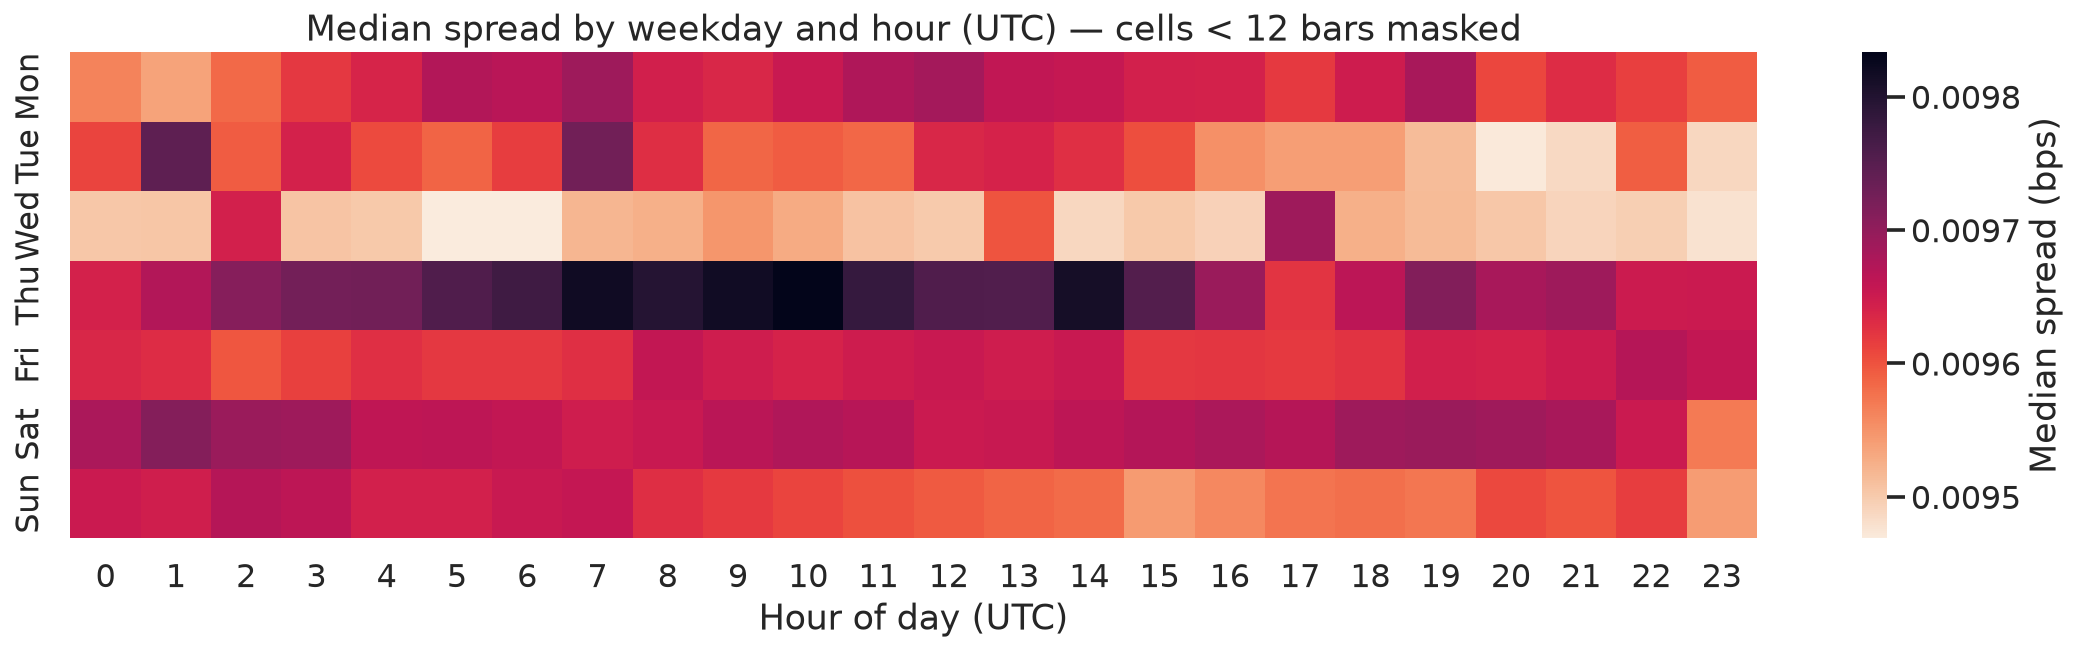

In [6]:
spread_grid, spread_counts = season_pivot(df, "spread_bps", "median")
spread_masked = spread_grid.mask(spread_counts < MIN_CELL_BARS)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(spread_masked, cmap="rocket_r", ax=ax, cbar_kws={"label": "Median spread (bps)"})
ax.set_title(f"Median spread by weekday and hour (UTC) — cells < {MIN_CELL_BARS} bars masked")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("")
plt.tight_layout()

## Chart 2 — Multi-level depth seasonality

The order book is more than the top level. The left panel is an hour/day heatmap
of total depth at level `DEPTH_LEVEL`; the right panel compares the average
depth profile by hour across the 5/10/20/25 aggregation levels, showing how much
more notional deeper levels add.

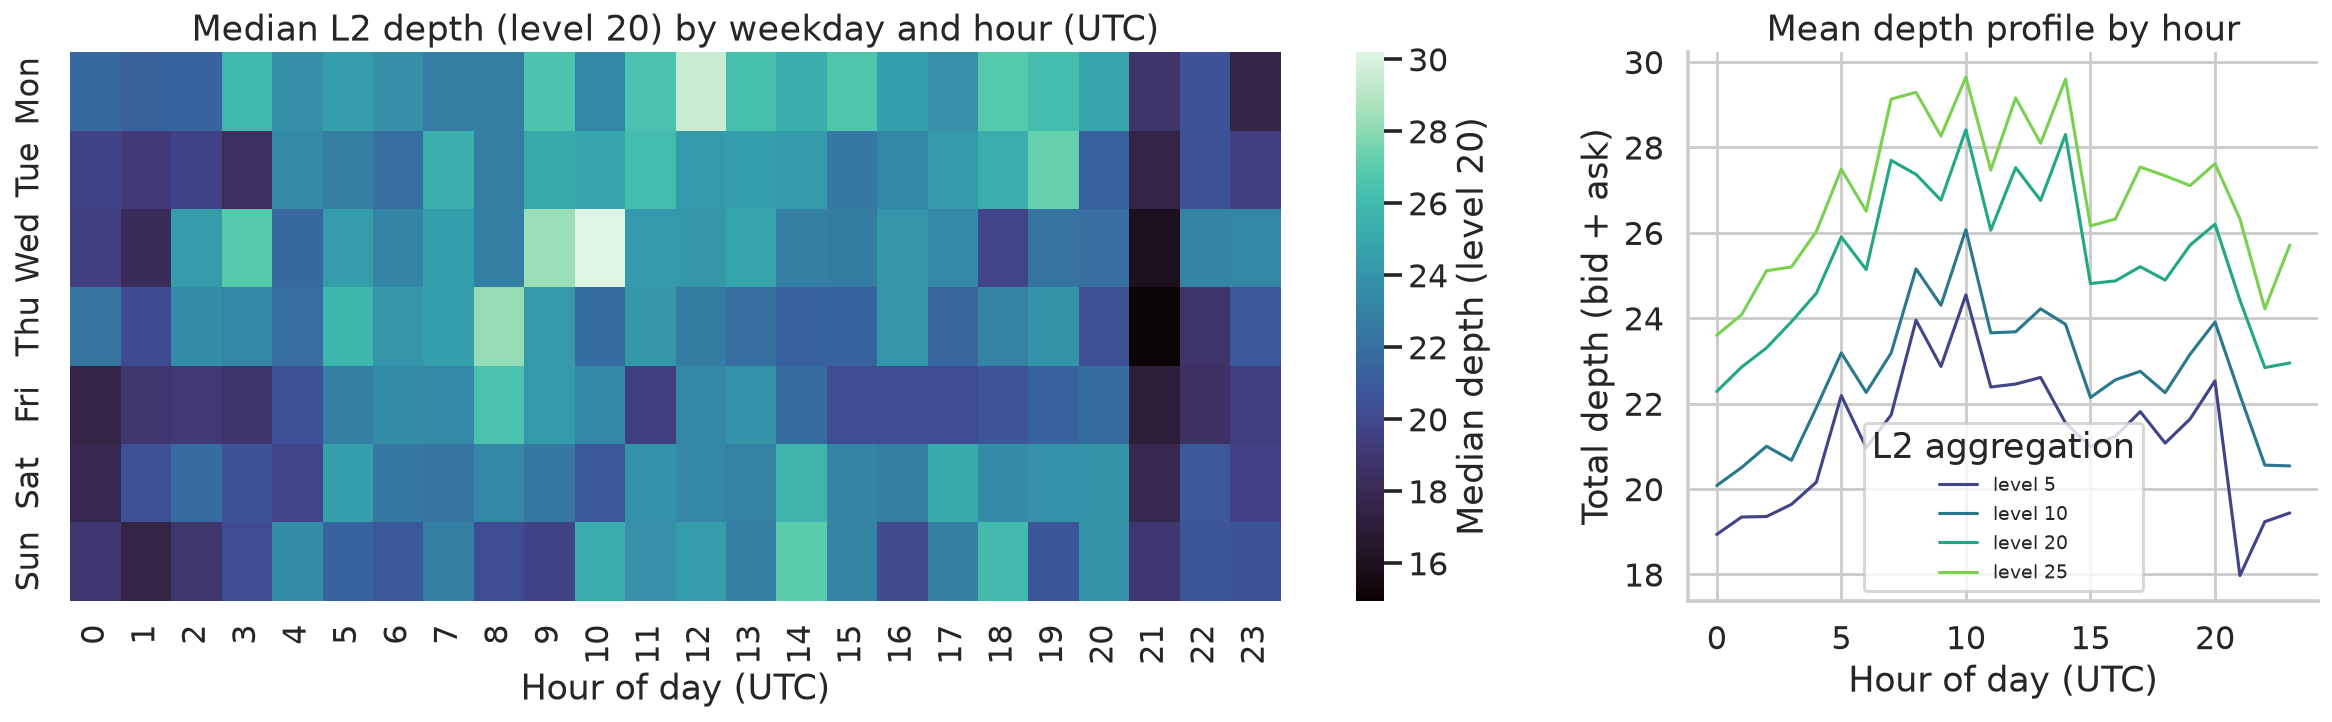

In [7]:
depth_grid, depth_counts = season_pivot(df, f"depth_{DEPTH_LEVEL}", "median")
depth_masked = depth_grid.mask(depth_counts < MIN_CELL_BARS)

fig, (ax_h, ax_p) = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [2.4, 1]})
sns.heatmap(depth_masked, cmap="mako", ax=ax_h, cbar_kws={"label": f"Median depth (level {DEPTH_LEVEL})"})
ax_h.set_title(f"Median L2 depth (level {DEPTH_LEVEL}) by weekday and hour (UTC)")
ax_h.set_xlabel("Hour of day (UTC)")
ax_h.set_ylabel("")

hourly_depth = df.groupby("hour")[[f"depth_{lvl}" for lvl in L2_LEVELS]].mean()
palette = sns.color_palette("viridis", len(L2_LEVELS))
for color, lvl in zip(palette, L2_LEVELS):
    ax_p.plot(hourly_depth.index, hourly_depth[f"depth_{lvl}"], color=color, linewidth=1.6, label=f"level {lvl}")
ax_p.set_title("Mean depth profile by hour")
ax_p.set_xlabel("Hour of day (UTC)")
ax_p.set_ylabel("Total depth (bid + ask)")
ax_p.legend(frameon=True, fontsize=10, title="L2 aggregation")
plt.tight_layout()

## Chart 3 — Volatility and adverse flow

Execution risk is not only about nominal depth. The left panel overlays rolling
realised volatility with the average spread by hour. The right panel relates a
**lagged** toxicity reading to the **next-bar** absolute move: bucketing by the
toxicity quintile *known before* the move, average subsequent moves rise with
toxicity. This is a toxicity-style diagnostic, not a causal claim.

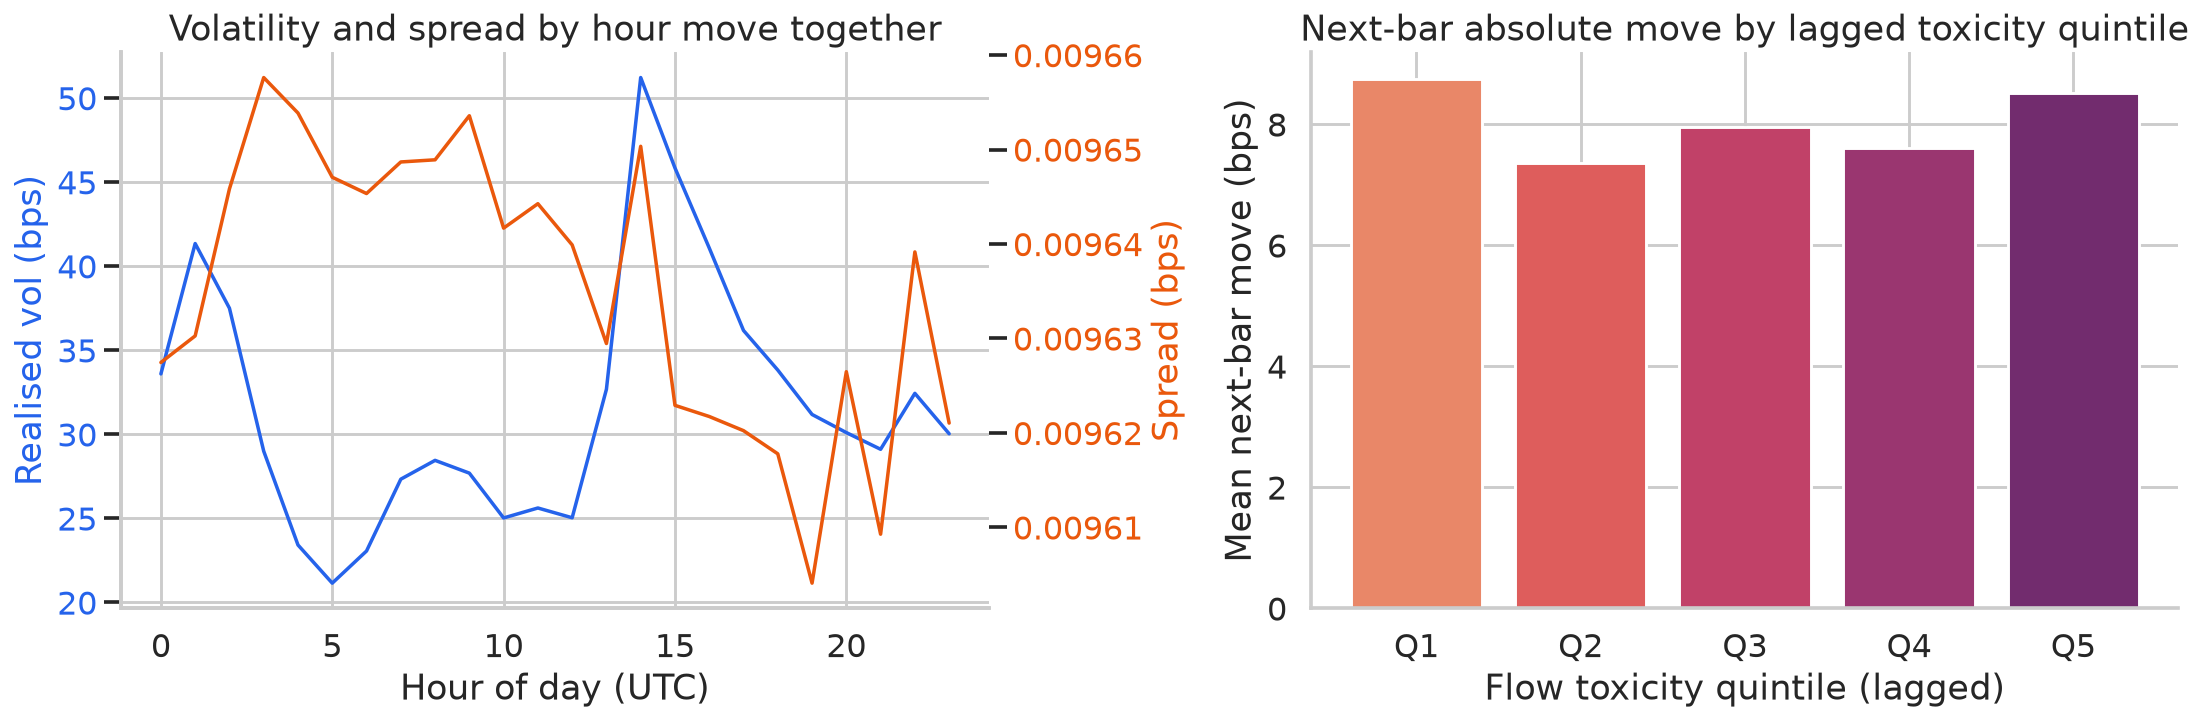

In [8]:
fig, (ax_v, ax_t) = plt.subplots(1, 2, figsize=(16, 5.5))

hourly = df.groupby("hour").agg(spread_bps=("spread_bps", "median"), vol_bps=("realized_vol_1h_bps", "median"))
ax_v.plot(hourly.index, hourly["vol_bps"], color="#2563eb", linewidth=1.8, label="Median realised vol (bps)")
ax_v.set_xlabel("Hour of day (UTC)")
ax_v.set_ylabel("Realised vol (bps)", color="#2563eb")
ax_v.tick_params(axis="y", labelcolor="#2563eb")
ax_vs = ax_v.twinx()
ax_vs.plot(hourly.index, hourly["spread_bps"], color="#ea580c", linewidth=1.8, label="Median spread (bps)")
ax_vs.set_ylabel("Spread (bps)", color="#ea580c")
ax_vs.tick_params(axis="y", labelcolor="#ea580c")
ax_vs.grid(False)
ax_v.set_title("Volatility and spread by hour move together")

tox = df[["flow_toxicity_score", "fwd_abs_move_bps"]].dropna().copy()
tox["tox_quintile"] = pd.qcut(tox["flow_toxicity_score"], 5, labels=[f"Q{i}" for i in range(1, 6)], duplicates="drop")
by_q = tox.groupby("tox_quintile", observed=True)["fwd_abs_move_bps"].mean()
ax_t.bar(by_q.index.astype(str), by_q.to_numpy(), color=sns.color_palette("flare", len(by_q)))
ax_t.set_title("Next-bar absolute move by lagged toxicity quintile")
ax_t.set_xlabel("Flow toxicity quintile (lagged)")
ax_t.set_ylabel("Mean next-bar move (bps)")
plt.tight_layout()

## 7. Build a liquidity score and scheduler

A transparent, equal-weight **liquidity score** combines four percentile-ranked
inputs so that *higher is better*: narrow spread, deep book, low impact, low
toxicity. Ranks are computed over the whole in-window sample (in-window
calibration), and hours are ranked by their mean score — a decision made from
historical bins, never from a row's own future.

Expected one-way cost for a $50,000 order, by schedule (bps):
| schedule          | hours          |   mean_cost_bps |   diff_vs_uniform_bps |
|:------------------|:---------------|----------------:|----------------------:|
| Best 4 hours      | [7, 9, 11, 13] |        0.171198 |            -0.0429456 |
| Uniform (all day) | all 24         |        0.214144 |             0         |
| Worst 4 hours     | [0, 1, 21, 22] |        0.153881 |            -0.0602632 |


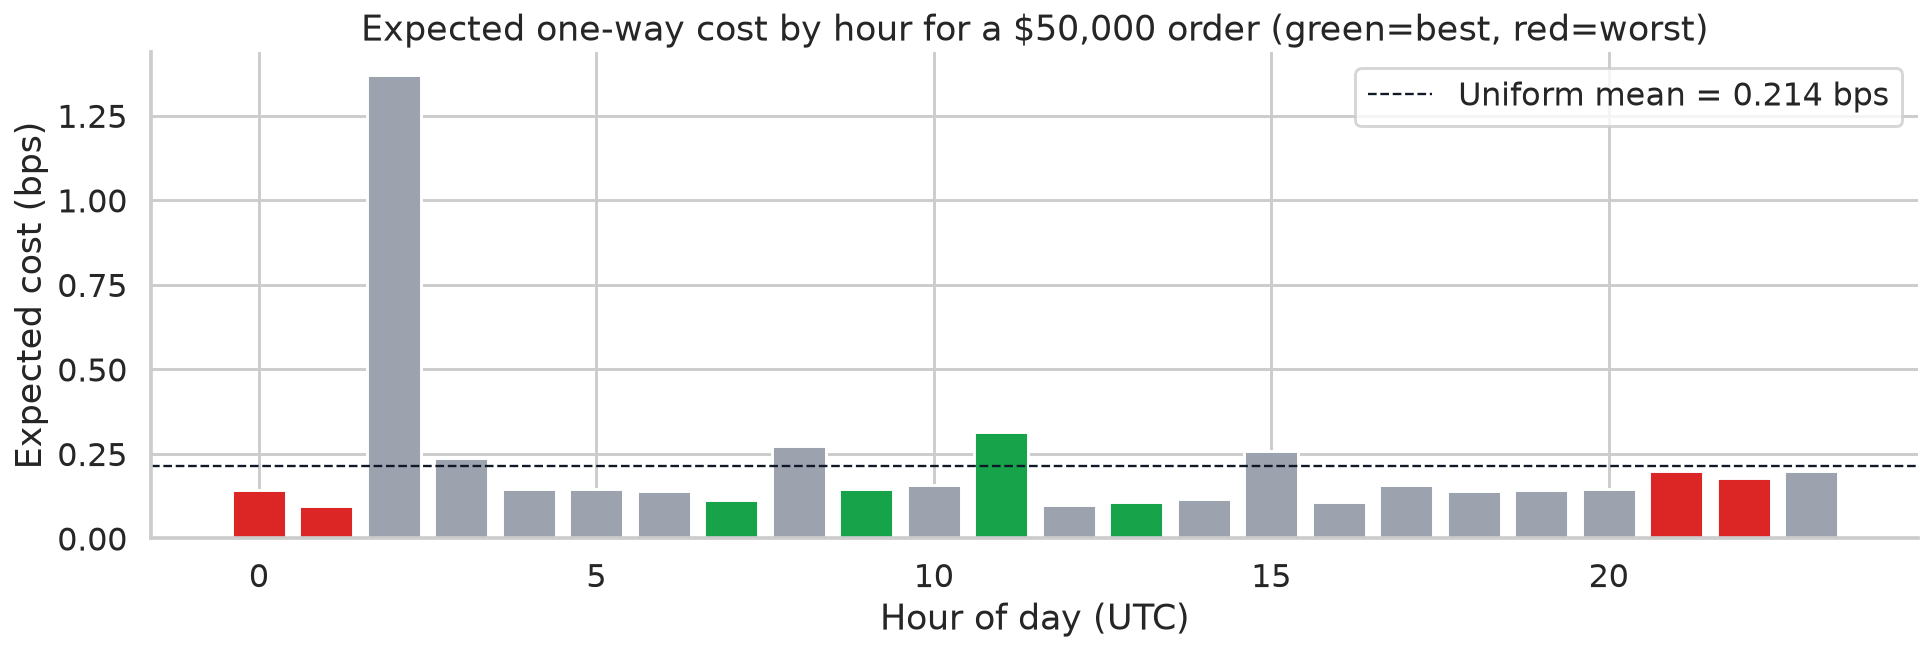

In [9]:
df["score_spread"] = 1.0 - pct_rank(df["spread_bps"])
df["score_depth"] = pct_rank(df[f"depth_{DEPTH_LEVEL}"])
df["score_impact"] = 1.0 - pct_rank(df["impact_coef_bps_per_usd"])
df["score_toxicity"] = 1.0 - pct_rank(df["flow_toxicity_score"])
df["liquidity_score"] = df[["score_spread", "score_depth", "score_impact", "score_toxicity"]].mean(axis=1)

hourly_stats = (
    df.groupby("hour")
    .agg(liquidity_score=("liquidity_score", "mean"), expected_cost_bps=("expected_cost_bps", "mean"))
    .sort_values("liquidity_score", ascending=False)
)
best_hours = hourly_stats.head(BEST_K_HOURS).index.tolist()
worst_hours = hourly_stats.tail(BEST_K_HOURS).index.tolist()

uniform_cost = df["expected_cost_bps"].mean()
best_cost = df.loc[df["hour"].isin(best_hours), "expected_cost_bps"].mean()
worst_cost = df.loc[df["hour"].isin(worst_hours), "expected_cost_bps"].mean()

schedules = pd.DataFrame(
    [
        {"schedule": f"Best {BEST_K_HOURS} hours", "hours": sorted(best_hours), "mean_cost_bps": best_cost},
        {"schedule": "Uniform (all day)", "hours": "all 24", "mean_cost_bps": uniform_cost},
        {"schedule": f"Worst {BEST_K_HOURS} hours", "hours": sorted(worst_hours), "mean_cost_bps": worst_cost},
    ]
)
schedules["diff_vs_uniform_bps"] = schedules["mean_cost_bps"] - uniform_cost
print(f"Expected one-way cost for a ${ORDER_NOTIONAL:,} order, by schedule (bps):")
print(schedules.to_markdown(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    hourly_stats.sort_index().index,
    hourly_stats.sort_index()["expected_cost_bps"],
    color=[
        "#16a34a" if h in best_hours else "#dc2626" if h in worst_hours else "#9ca3af"
        for h in hourly_stats.sort_index().index
    ],
)
ax.axhline(uniform_cost, color="#111827", linestyle="--", linewidth=1.2, label=f"Uniform mean = {uniform_cost:.3f} bps")
ax.set_title(f"Expected one-way cost by hour for a ${ORDER_NOTIONAL:,} order (green=best, red=worst)")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Expected cost (bps)")
ax.legend(frameon=True)
plt.tight_layout()

## Chart 4 — When to stand aside

A single liquidity measure can mislead: some hours look deep but carry elevated
adverse-flow risk. The scatter places each hour by mean depth (x) against mean
toxicity (y); the best-schedule hours are green, worst are red. Watch the
**high-depth, high-toxicity** quadrant — nominal liquidity that can still fill
you adversely.

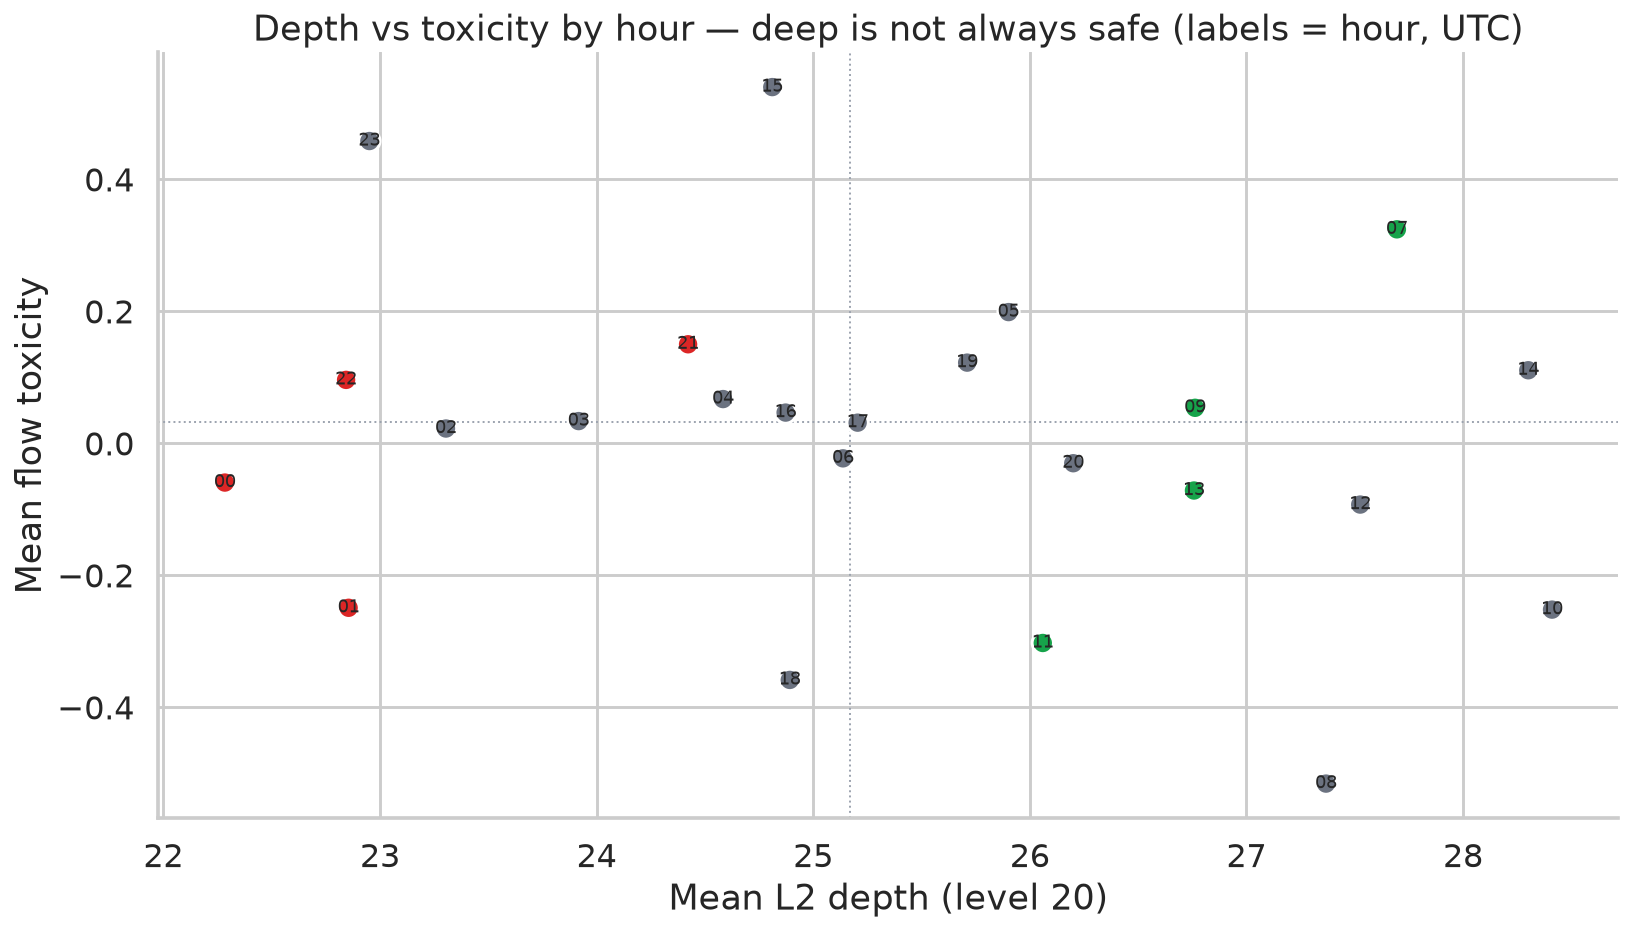

In [10]:
hour_scatter = df.groupby("hour").agg(
    depth=(f"depth_{DEPTH_LEVEL}", "mean"),
    toxicity=("flow_toxicity_score", "mean"),
    cost=("expected_cost_bps", "mean"),
)
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#16a34a" if h in best_hours else "#dc2626" if h in worst_hours else "#6b7280" for h in hour_scatter.index]
ax.scatter(hour_scatter["depth"], hour_scatter["toxicity"], s=120, c=colors, edgecolor="white", zorder=3)
for h, row in hour_scatter.iterrows():
    ax.annotate(f"{h:02d}", (row["depth"], row["toxicity"]), fontsize=9, ha="center", va="center")
ax.axhline(hour_scatter["toxicity"].median(), color="#9ca3af", linestyle=":", linewidth=1)
ax.axvline(hour_scatter["depth"].median(), color="#9ca3af", linestyle=":", linewidth=1)
ax.set_title("Depth vs toxicity by hour — deep is not always safe (labels = hour, UTC)")
ax.set_xlabel(f"Mean L2 depth (level {DEPTH_LEVEL})")
ax.set_ylabel("Mean flow toxicity")
plt.tight_layout()

## Takeaways

- **When beats how, for moderate size.** In this window the best-hour schedule
  (`BEST_K_HOURS` = 4) costs meaningfully less than uniform, and the worst-hour
  schedule meaningfully more, for a fixed `ORDER_NOTIONAL` order (Section 7).
- **Cost scales with order size.** The impact term grows with notional, so the
  schedule gap widens for larger orders — re-run with your own `ORDER_NOTIONAL`.
- **Deep is not always safe.** Chart 4 shows hours with ample depth but elevated
  toxicity; a scheduler on depth alone would walk into them.
- **Historical, not Live.** These bins are calibrated in-window; operating the
  schedule forward needs Live data, and full L2 **history** requires Prime. All
  calls shown run on the preview key, and every figure is illustrative.

## Further reading
- [Execute smarter](https://aperiodic.io/use-cases/execute-smarter)
- [L1 metrics](https://aperiodic.io/metrics/l1) · [L2 metrics](https://aperiodic.io/metrics/l2) · [Trade metrics](https://aperiodic.io/metrics/trades)
- Cost-model prerequisite: `notebooks/backtest-slippage.py`
- Related notebook: `notebooks/intro-l1-price.py`